# Derivation of generalized earth-return impedance and admittance formulas

This script analyzes the behavior of a two-wire transmission line using the method of moments (MoM).
The code is structured into classes and functions, facilitating a modular approach to the problem. 

REFERENCES:
[1] 

In [6]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from ohtl.pul_parameters import PerUnitParameters
from data.systems import MULTICONDUCTOR_TRANSMISSION_LINE
from data.graph import GraphicRepresentation

Multiconductor Transmission Line choices
1 - Xue's single overhead conductor: h1 = 10 m, r1 = 1 cm and rho_c = 1.68E-8 S/m

In [7]:
MTL = MULTICONDUCTOR_TRANSMISSION_LINE[1]

This function plots the series resistance as a function of frequency.

    Parameters:
    freq (array): Frequency array.
    zi_matrix (list of matrices): Matrix containing impedance values.
    p (int): Row index in the impedance matrix.
    q (int): Column index in the impedance matrix.

In [8]:
def plot_impedance(freq, pul_dict, p, q):
    """
    This function plots the series resistance as a function of frequency.

    Parameters:
    freq (array): Frequency array.
    zi_matrix (list of matrices): Matrix containing impedance values.
    p (int): Row index in the impedance matrix.
    q (int): Column index in the impedance matrix.
    """

    # Frequency array
    f = np.array(freq['Analytically'])

    # Extracting the impedance elements from zi_matrix
    z_a = np.array([item['Zs'][p, q] for item in pul_dict['a']]) # pylint: disable=line-too-long # Np/km
    z_b = np.array([item['Zs'][p, q] for item in pul_dict['b']]) # pylint: disable=line-too-long # Np/km
    z_c = np.array([item['Zs'][p, q] for item in pul_dict['c']]) # pylint: disable=line-too-long # Np/km
    l_a = np.imag(z_a) / (2 * np.pi * f)  # H/m
    l_b = np.imag(z_b) / (2 * np.pi * f)  # H/m
    l_c = np.imag(z_c) / (2 * np.pi * f)  # H/m

    plt.plot(f, 1E3 * np.real(z_a), label=r'$\rho_e=100 \Omega m, \epsilon_r=1$', color='black', linestyle='-')  # pylint: disable=line-too-long
    plt.plot(f, 1E3 * np.real(z_b), label=r'$\rho_e=100 \Omega m, \epsilon_r=20$', color='black', linestyle='--')  # pylint: disable=line-too-long
    plt.plot(f, 1E3 * np.real(z_c), label=r'$\rho_e=2000 \Omega m, \epsilon_r=1$', color='black', linestyle='-.')  # pylint: disable=line-too-long

    # Additional plotting configurations
    plt.xscale('log')
    plt.yscale('log')
    plt.xlim(1E3, 1E9)
    plt.ylim(1E0, 1E5)
    plt.legend()
    plt.xlabel('Frequency (Hz)')
    plt.ylabel(r'$R_s \, (\Omega/km)$')
    plt.grid(True)

    # Adjust the layout of the plots
    plt.suptitle('P.u.l. series resistance of the single overhead line\n'
                 r'$r_1 = 0.01\,\mathrm{m}, h_1 = 10\,\mathrm{m}, \rho = 1.68 \times 10^{-8} \, \mathrm{\Omega m}$ [1]') # pylint: disable=line-too-long
    plt.tight_layout()
    plt.show()

    # Extracting the impedance elements from zi_matrix
    plt.plot(f, 1E6 * l_a, label=r'$\rho_e=100 \, \Omega m, \epsilon_r=1$', color='black', linestyle='-')  # pylint: disable=line-too-long
    plt.plot(f, 1E6 * l_b, label=r'$\rho_e=100 \, \Omega m, \epsilon_r=20$', color='black', linestyle='--')  # pylint: disable=line-too-long
    plt.plot(f, 1E6 * l_c, label=r'$\rho_e=2000 \; \Omega m, \epsilon_r=1$', color='black', linestyle='-.')  # pylint: disable=line-too-long

    # Additional plotting configurations
    plt.xscale('log')
    plt.xlim(1E3, 1E9)
    plt.ylim(1, 2.5)
    plt.legend()
    plt.xlabel('Frequency (Hz)')
    plt.ylabel(r'$L_s \, (mH/km)$')
    plt.grid(True)

    # Adjust the layout of the plots
    plt.suptitle('P.u.l. series inductance of the single overhead line\n'
                 r'$r_1 = 0.01 \, \mathrm{m}, h_1 = 10 \, \mathrm{m}, \rho = 1.68 \times 10^{-8} \, \mathrm{\Omega m}$ [1]') # pylint: disable=line-too-long
    plt.tight_layout()
    plt.show()

Main function to perform the calculations and display the results.

In [9]:
os.system('cls' if os.name == 'nt' else 'clear')
print("Calculations were started ... ...")
start_time = time.time()

Calculations were started ... ...


### Calculate the series impedance for each frequency

In [10]:
frequency = {'Analytically': np.logspace(3, 9, num=200), 'Numerically': np.logspace(0, 7, num=30)}

### Dictionary to hold the series impedance calculations

In [11]:
pul_dict = {'a': [], 'b': [], 'c': []}

### Analytical Formulation

In [12]:
for f in frequency['Analytically']:
    pul_a = PerUnitParameters(MTL, f, sigma_1=1/1E2, er_1=1)
    pul_b = PerUnitParameters(MTL, f, sigma_1=1/1E2, er_1=20)
    pul_c = PerUnitParameters(MTL, f, sigma_1=1/2E3, er_1=1)

    # Internal and external impedance matrices
    pul_dict['a'].append(pul_a.pul_extended_theory())
    pul_dict['b'].append(pul_b.pul_extended_theory())
    pul_dict['c'].append(pul_c.pul_extended_theory())

### End the timer

In [13]:
elapsed_time = time.time() - start_time
print(f"End of the routine! Time spent on simulation: {elapsed_time:.2f} seconds.\n")

End of the routine! Time spent on simulation: 16.18 seconds.



### Display the geometry of the transmission line

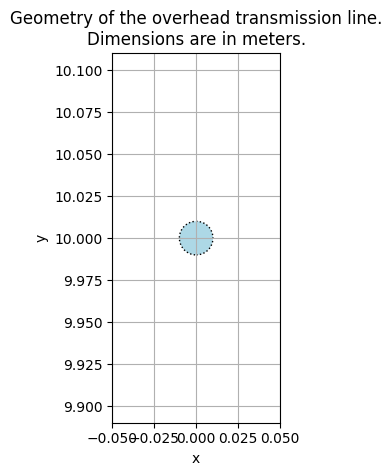

In [14]:
GraphicRepresentation(MTL).wires_and_cables(line_type='overhead')

### Plot the series resistance as a function of frequency


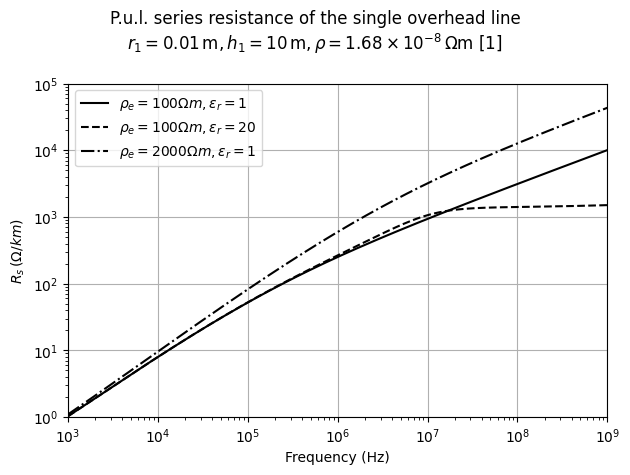

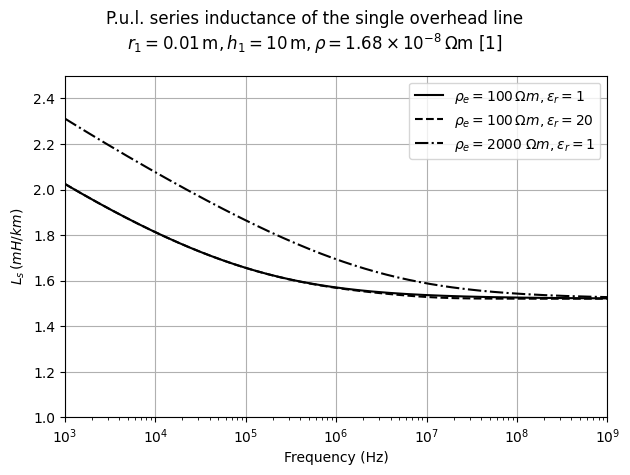

In [15]:
plot_impedance(frequency, pul_dict, p=0, q=0)